## Load and Inspect

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
# Visual
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

# Load dataset
df = pd.read_csv(
    "../data/raw/National Grid Data 2009-2025.csv",
    header=2, #skip metadata
    low_memory=False
)

# Drop empty rows
df = df.dropna(how="all")

# Rename columns by POSITION to avoid hidden-character issues
df.rename(columns={
    df.columns[0]: "SETTLEMENT_DATE",
    df.columns[1]: "SETTLEMENT_PERIOD",
    df.columns[4]: "ENGLAND_WALES_DEMAND"
}, inplace=True)

# Convert settlement date to datetime (Forcing UK day-first format)
df["SETTLEMENT_DATE"] = pd.to_datetime(
    df["SETTLEMENT_DATE"],
    dayfirst=True, 
    errors="coerce"
)

# Forward-fill settlement date (critical for this dataset)
df["SETTLEMENT_DATE"] = df["SETTLEMENT_DATE"].ffill()

# Convert settlement period to numeric
df["SETTLEMENT_PERIOD"] = pd.to_numeric(
    df["SETTLEMENT_PERIOD"],
    errors="coerce"
)

# Construct true timestamp (each period = 30 minutes)
df["timestamp"] = (
    df["SETTLEMENT_DATE"]
    + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
)

# Drop rows where timestamp could not be constructed
df = df.dropna(subset=["timestamp"])

# Set timestamp as index, drop duplicates, and sort
df = df.set_index("timestamp")
df = df[~df.index.duplicated(keep='first')] # Removes overlapping duplicates
df = df.sort_index()

# Force a strict 30-minute frequency to expose any hidden missing gaps
df = df.asfreq('30min')

# Select target variable and rename
df = df[["ENGLAND_WALES_DEMAND"]].rename(columns={"ENGLAND_WALES_DEMAND": "demand"})

print("Data loading and index creation complete. Shape:", df.shape)

C:\Users\ariel\AppData\Local\Temp\ipykernel_90820\2577799065.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["SETTLEMENT_DATE"] = pd.to_datetime(


Data loading and index creation complete. Shape: (282144, 1)


In [ ]:
# Preview
df.head()

,demand
timestamp,
2009-01-01 00:00:00,33939
2009-01-01 00:30:00,34072
2009-01-01 01:00:00,33615
2009-01-01 01:30:00,32526
2009-01-01 02:00:00,31877


In [ ]:
# Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 282144 entries, 2009-01-01 00:00:00 to 2025-02-03 23:30:00
Freq: 30min
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   demand  282112 non-null  object
dtypes: object(1)
memory usage: 4.3+ MB


## Handle Missing Values

In [ ]:
df["demand"] = pd.to_numeric(df["demand"], errors="coerce")

# Replace artificial 0.0 values with NaN so they don't skew the data
df["demand"] = df["demand"].replace(0.0, np.nan)

print("Missing values before interpolation:", df["demand"].isna().sum())

# Interpolate the gaps using time-based interpolation
df["demand"] = df["demand"].interpolate(method="time")

print("Missing values after interpolation:", df["demand"].isna().sum())

Missing values before interpolation: 53
Missing values after interpolation: 0


## Stationarity (ADF Test)

In [10]:
adf_result = adfuller(df["demand"].dropna())
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# Create differenced series ONLY for ARIMA
df["demand_diff"] = df["demand"].diff()

ADF Statistic: -16.262624694788688
p-value: 3.55310372906866e-29


## EDA

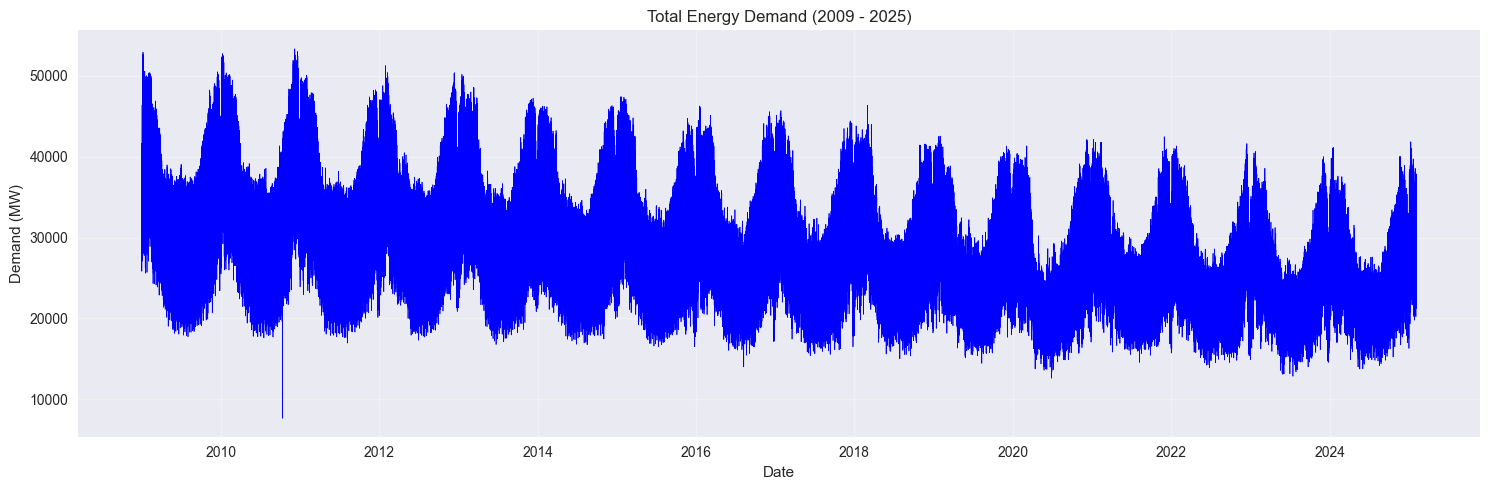

In [11]:
#Clean Macro-Timeline
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['demand'], color='blue', linewidth=0.5)
plt.title('Total Energy Demand (2009 - 2025)')
plt.ylabel('Demand (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\ariel\AppData\Local\Temp\ipykernel_90820\62186562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='demand', data=df, palette='viridis')


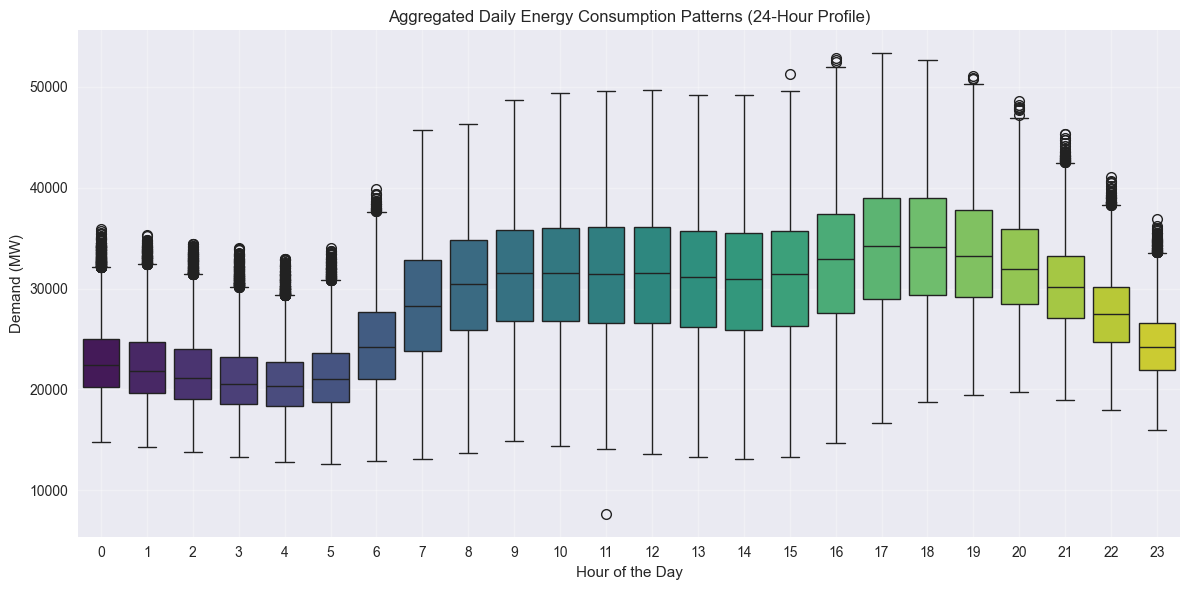

In [12]:
#Daily 24-Hour Profile
df['hour'] = df.index.hour

plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='demand', data=df, palette='viridis')
plt.title('Aggregated Daily Energy Consumption Patterns (24-Hour Profile)')
plt.ylabel('Demand (MW)')
plt.xlabel('Hour of the Day')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

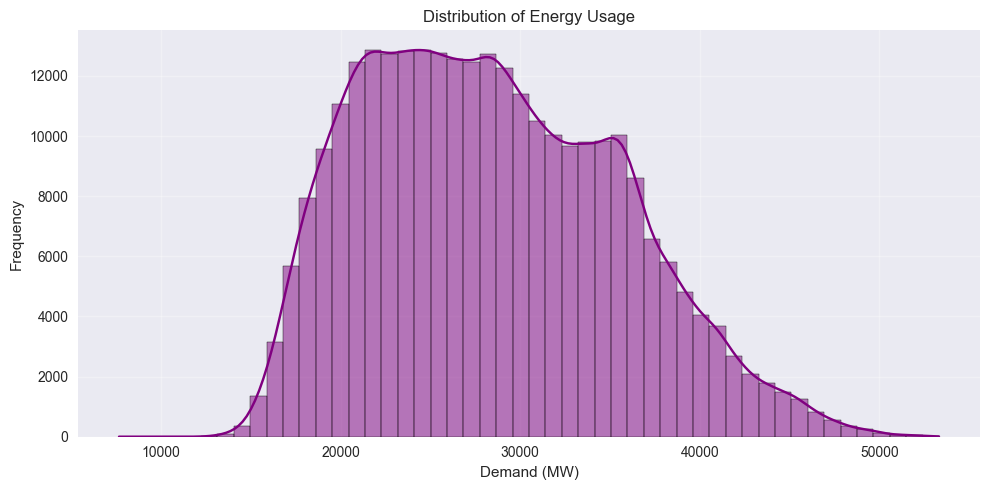

In [13]:
#Distribution of Usage
plt.figure(figsize=(10, 5))
sns.histplot(df['demand'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Energy Usage')
plt.xlabel('Demand (MW)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\ariel\AppData\Local\Temp\ipykernel_90820\2806278176.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_name', y='demand', data=df,
C:\Users\ariel\AppData\Local\Temp\ipykernel_90820\2806278176.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='demand', data=df, ax=axes[1], palette='coolwarm')


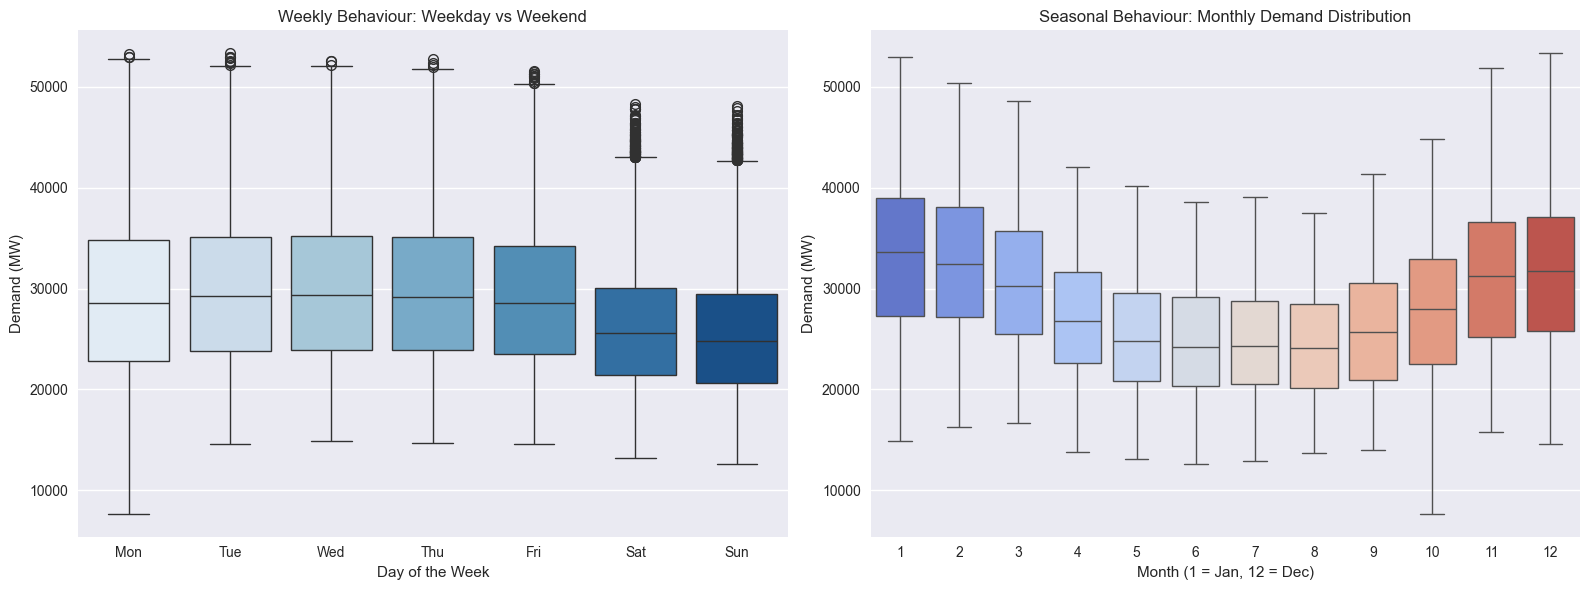

In [ ]:
# Weekly and Seasonal Behaviour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# Map numbers to names for a cleaner plot
days = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['day_name'] = df['day_of_week'].map(days)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Weekend vs Weekday plot
sns.boxplot(x='day_name', y='demand', data=df, 
            order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 
            ax=axes[0], palette='Blues')
axes[0].set_title('Weekly Behaviour: Weekday vs Weekend')
axes[0].set_ylabel('Demand (MW)')
axes[0].set_xlabel('Day of the Week')

# Summer vs Winter plot
sns.boxplot(x='month', y='demand', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Seasonal Behaviour: Monthly Demand Distribution')
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('Month (1 = Jan, 12 = Dec)')

plt.tight_layout()
plt.show()

# Clean up the temporary columns before saving
df = df.drop(columns=['hour', 'day_of_week', 'month', 'day_name'])

## Saved Processed Data

In [17]:
# Create final clean copy
df_cleaned = df.copy()

print(df_cleaned.tail())

# Note: Add your save-to-CSV line here if needed, for example:
df_cleaned.to_csv("../data/processed/cleaned_demand_2009_2025.csv")


                      demand  demand_diff
timestamp                                
2025-02-03 21:30:00  29004.0      -1769.0
2025-02-03 22:00:00  27386.0      -1618.0
2025-02-03 22:30:00  25517.0      -1869.0
2025-02-03 23:00:00  24005.0      -1512.0
2025-02-03 23:30:00  23154.0       -851.0
